In [ ]:
# Importing the libraries we need
# pandas → for loading and working with data (like Excel but in Python)
# matplotlib → base library for creating charts
# seaborn → built on matplotlib, makes better-looking charts easily

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Seaborn has the Iris dataset built-in
# We load it directly — no CSV file needed
# 'df' stands for dataframe, which is like a table/spreadsheet in Python

df = sns.load_dataset('iris')

In [ ]:
# .shape tells us rows and columns → (150, 5) means 150 rows, 5 columns
print("Shape:", df.shape)

# .columns shows all column names
print("\nColumns:", df.columns.tolist())

# .head() shows first 5 rows so we can see what the data looks like
print("\nFirst 5 rows:")
df.head()

Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# .describe() gives us count, mean, min, max, std for every numeric column
# This helps us understand the range and spread of measurements

df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Always check for missing values before analysis
# isnull().sum() counts how many empty/null values are in each column
# Iris dataset has none — but good habit to always check

print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
# value_counts() tells us how many records exist per species
# Iris is perfectly balanced → 50 records each
# Balanced data = no bias issue in modeling later

print("Species count:")
df['species'].value_counts()

Species count:


,count
species,
setosa,50
versicolor,50
virginica,50


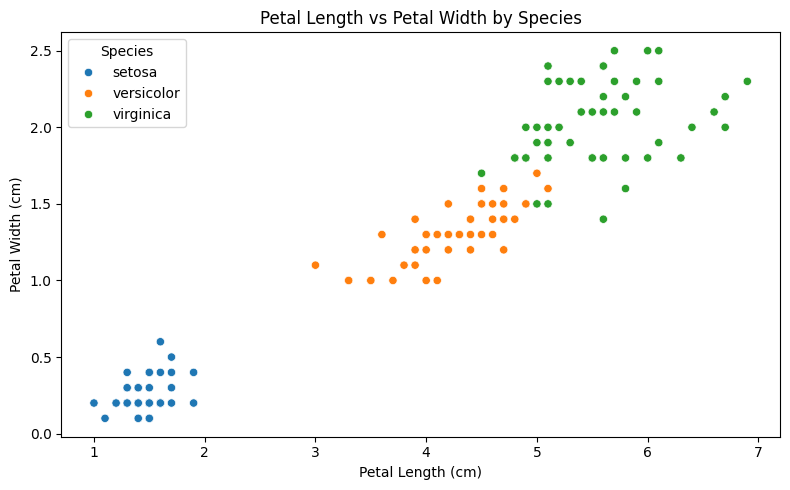

In [ ]:
# Scatter plot: petal_length (x-axis) vs petal_width (y-axis)
# hue='species' colors each dot by species so we can visually separate them
# This is the most important chart — shows Setosa is clearly different

plt.figure(figsize=(8, 5))  # sets chart size width=8, height=5
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')

plt.title('Petal Length vs Petal Width by Species')  # chart title
plt.xlabel('Petal Length (cm)')   # x-axis label
plt.ylabel('Petal Width (cm)')    # y-axis label
plt.legend(title='Species')       # shows color legend
plt.tight_layout()                # prevents labels from getting cut off
plt.show()                        # displays the chart

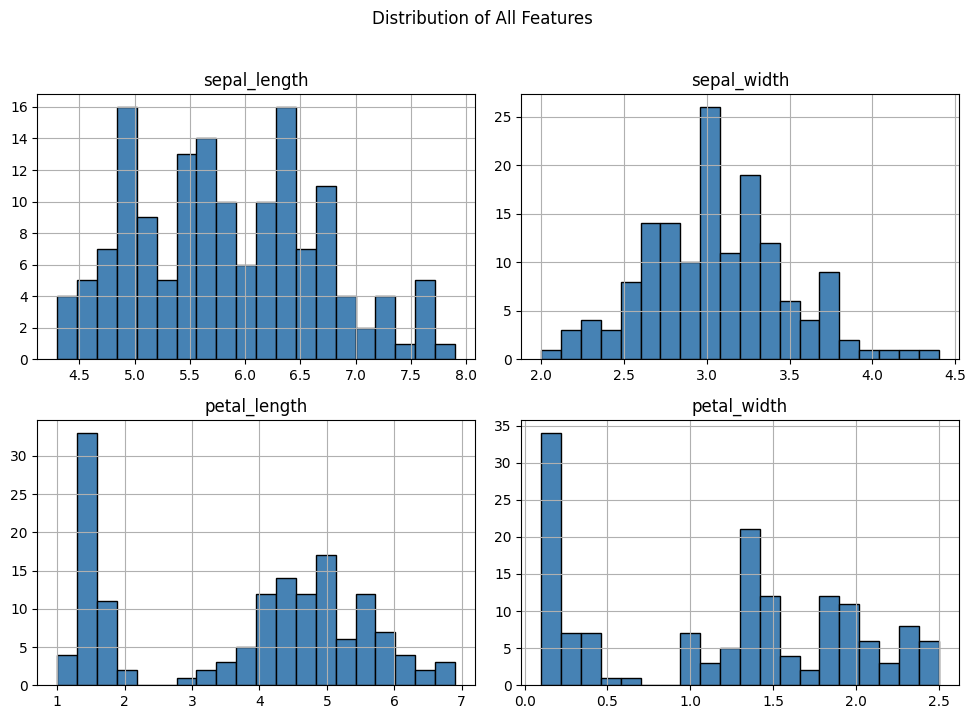

In [ ]:
# Histogram shows the distribution (spread) of each measurement
# We plot all 4 numeric features in one figure using a loop
# bins=20 means divide the data into 20 buckets
# kde=True adds a smooth curve on top showing the distribution shape

df.hist(bins=20, figsize=(10, 7), color='steelblue', edgecolor='black')

plt.suptitle('Distribution of All Features', y=1.02)  # main title above all charts
plt.tight_layout()
plt.show()

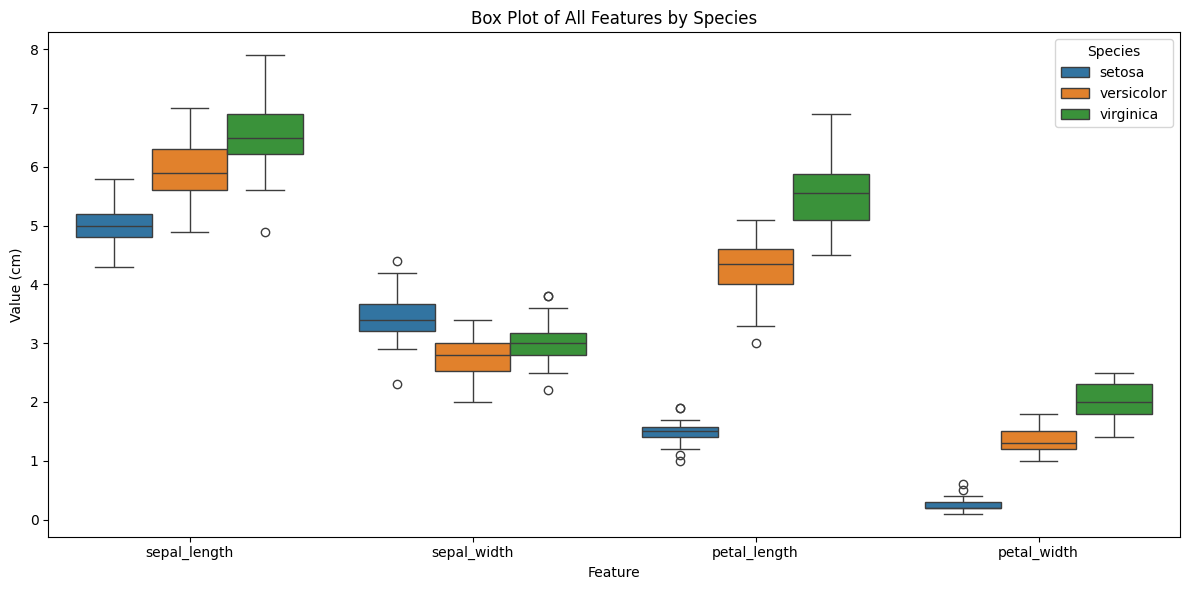

In [ ]:
# Box plot shows spread, median, and outliers for each species per feature
# We use melt() to reshape the data so seaborn can plot all features together
# melt converts wide format to long format — makes multi-feature box plots easier

df_melted = df.melt(id_vars='species', var_name='feature', value_name='value')
# id_vars='species' → keep species column as-is
# var_name='feature' → the 4 measurement columns become one column called 'feature'
# value_name='value' → their values go into a column called 'value'

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='feature', y='value', hue='species')

plt.title('Box Plot of All Features by Species')
plt.xlabel('Feature')
plt.ylabel('Value (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

## Conclusion

- The Iris dataset contains 150 records across 3 species: Setosa, Versicolor, Virginica
- Dataset is perfectly balanced with 50 samples per species
- No missing values were found
- Scatter plot revealed that Setosa is clearly separable from the other two species based on petal size
- Histograms showed petal features follow a bimodal distribution — Setosa forms a separate group
- Box plots confirmed Setosa has significantly smaller petals, and sepal width contains a few outliers
- Petal length and petal width are the most useful features for distinguishing species